## FraudShield AI — Day 3
### SHAP Explainability — Why Was This Transaction Flagged?

Author: Suman Das | PNB 11 yrs | MTech IAR Jadavpur University|
Dataset: Credit Card Fraud Detection (Kaggle)
Model: XGBoost Base (94.94% Precision, 4 False Alarms)

## Cell 1 — Environment Setup

In [ ]:
# ── Permanent Environment Setup ──────────────────────────
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install",
                "shap", "xgboost",
                "--quiet",
                "--disable-pip-version-check"],
               capture_output=True)

import os
os.kill(os.getpid(), 9)

## Cell 2 - Library Verification

In [1]:
# ── Verify All Libraries ──────────────────────────────────
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print("=" * 45)
print("FRAUDSHIELD AI — DAY 3")
print("=" * 45)
print(f"shap     : {shap.__version__} ✓")
print(f"numpy    : {np.__version__} ✓")
print(f"pandas   : {pd.__version__} ✓")
print("=" * 45)
print("Ready for SHAP Explainability! 🚀")

Mounted at /content/drive
FRAUDSHIELD AI — DAY 3
shap     : 0.51.0 ✓
numpy    : 2.0.2 ✓
pandas   : 2.2.2 ✓
Ready for SHAP Explainability! 🚀


## Cell 3 — Load Model + Data

In [2]:
# ── Load Model and Data ───────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

drive_path = "/content/drive/MyDrive/Fraud_Detection_Project/"
data_path  = "/content/drive/MyDrive/creditcard.csv"

# Load model and scaler
xgb_model = joblib.load(drive_path + "fraudshield_xgb_model.pkl")
scaler    = joblib.load(drive_path + "fraudshield_scaler.pkl")

# Load and prepare data
df = pd.read_csv(data_path)
df = df.drop_duplicates()
df['Log_Amount'] = np.log1p(df['Amount'])
df['Hour']       = (df['Time'] / 3600).astype(int) % 24

feature_cols = [c for c in df.columns
                if c not in ['Time', 'Amount', 'Class']]

X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

X_test_scaled  = scaler.transform(X_test.values)
X_train_scaled = scaler.transform(X_train.values)

# Convert to DataFrame for SHAP
X_test_df  = pd.DataFrame(X_test_scaled,
                           columns=feature_cols)
X_train_df = pd.DataFrame(X_train_scaled,
                           columns=feature_cols)

print("=" * 45)
print("MODEL AND DATA LOADED")
print("=" * 45)
print(f"Model type    : {type(xgb_model).__name__}")
print(f"Test samples  : {len(X_test):,}")
print(f"Features      : {len(feature_cols)}")
print(f"Fraud in test : {y_test.sum()}")
print("✓ Ready for SHAP analysis!")

MODEL AND DATA LOADED
Model type    : XGBClassifier
Test samples  : 56,746
Features      : 30
Fraud in test : 95
✓ Ready for SHAP analysis!


## Cell 4 — SHAP TreeExplainer + Summary Plot

Computing SHAP values — this takes 2-3 minutes...
SHAP values shape : (56746, 30)
✓ SHAP values computed!


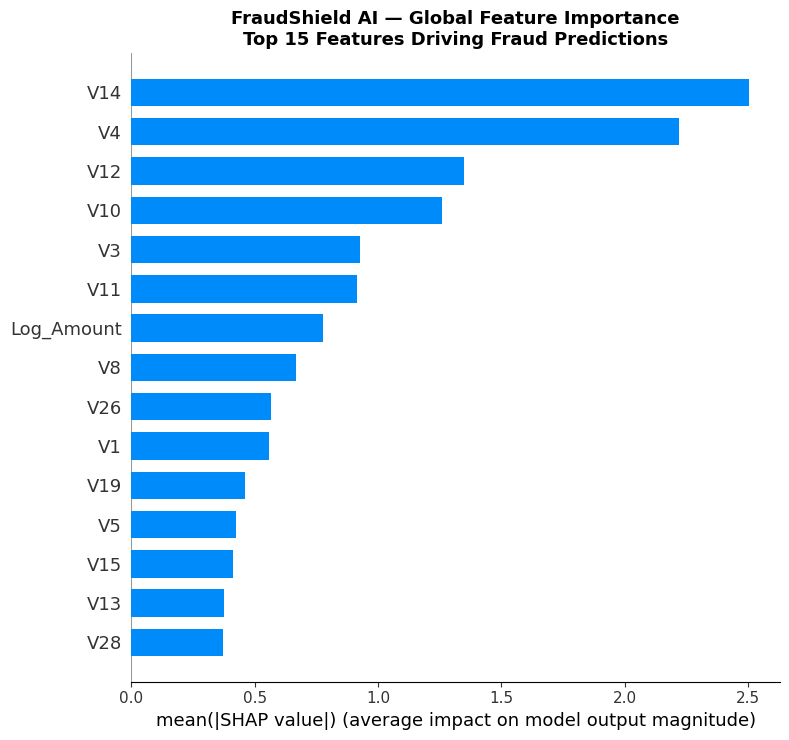

✓ Global importance plot saved!


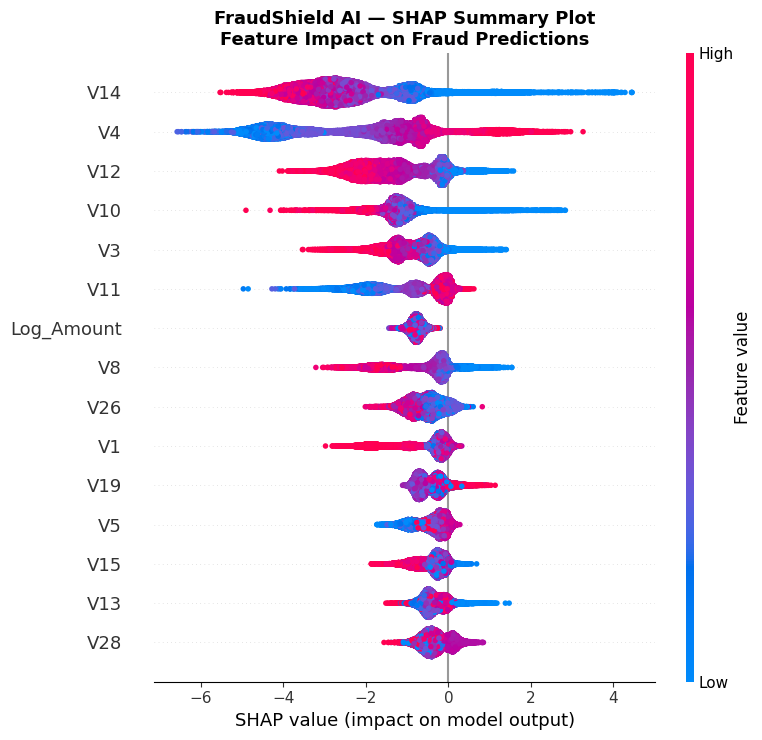


TOP 5 MOST IMPORTANT FEATURES:
  V14             : 2.5054
  V4              : 2.2228
  V12             : 1.3470
  V10             : 1.2609
  V3              : 0.9267


In [3]:
# ── SHAP TreeExplainer ────────────────────────────────────
print("Computing SHAP values — this takes 2-3 minutes...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values shape : {shap_values.shape}")
print("✓ SHAP values computed!")

# ── Summary Plot — Global Feature Importance ──────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type = "bar",
    max_display = 15,
    show = False
)
plt.title("FraudShield AI — Global Feature Importance\n"
          "Top 15 Features Driving Fraud Predictions",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Global importance plot saved!")

# ── Summary Dot Plot — Feature Impact ────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_df,
    max_display = 15,
    show = False
)
plt.title("FraudShield AI — SHAP Summary Plot\n"
          "Feature Impact on Fraud Predictions",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 45)
print("TOP 5 MOST IMPORTANT FEATURES:")
print("=" * 45)
feature_importance = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']:<15} : {row['importance']:.4f}")

## Cell 5 — Individual Transaction Explanation

INDIVIDUAL TRANSACTION ANALYSIS
Fraud transaction index  : 845
Legit transaction index  : 0

Fraud transaction — predicted fraud probability : 0.9959
Legit transaction — predicted fraud probability : 0.0000


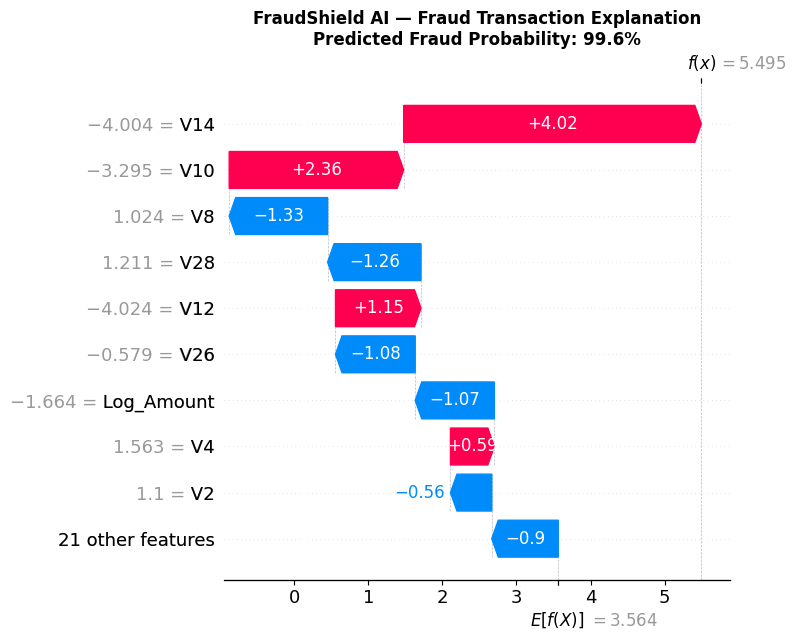

✓ Fraud explanation saved!


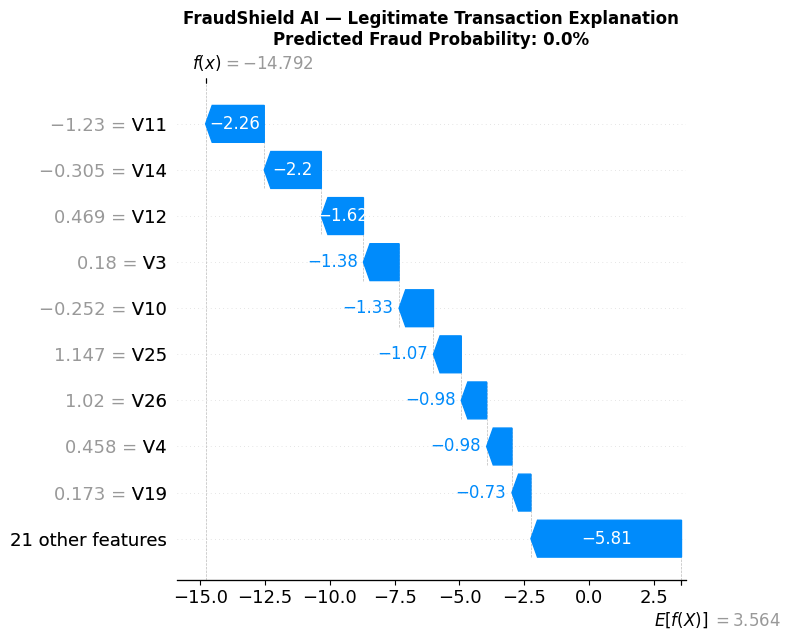

✓ Legitimate explanation saved!


In [4]:
# ── Find fraud and legitimate transactions ────────────────
y_test_reset = y_test.reset_index(drop=True)
fraud_indices = y_test_reset[y_test_reset == 1].index.tolist()
legit_indices = y_test_reset[y_test_reset == 0].index.tolist()

fraud_idx = fraud_indices[0]
legit_idx = legit_indices[0]

print("=" * 50)
print("INDIVIDUAL TRANSACTION ANALYSIS")
print("=" * 50)
print(f"Fraud transaction index  : {fraud_idx}")
print(f"Legit transaction index  : {legit_idx}")

fraud_prob = xgb_model.predict_proba(
    X_test_df.iloc[[fraud_idx]])[0][1]
legit_prob = xgb_model.predict_proba(
    X_test_df.iloc[[legit_idx]])[0][1]

print(f"\nFraud transaction — predicted fraud probability : {fraud_prob:.4f}")
print(f"Legit transaction — predicted fraud probability : {legit_prob:.4f}")

# ── Waterfall Plot — Fraud Transaction ───────────────────
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[fraud_idx],
        base_values   = explainer.expected_value,
        data          = X_test_df.iloc[fraud_idx].values,
        feature_names = feature_cols
    ),
    max_display = 10,
    show        = False
)
plt.title(f"FraudShield AI — Fraud Transaction Explanation\n"
          f"Predicted Fraud Probability: {fraud_prob:.1%}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_fraud_explanation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fraud explanation saved!")

# ── Waterfall Plot — Legitimate Transaction ───────────────
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[legit_idx],
        base_values   = explainer.expected_value,
        data          = X_test_df.iloc[legit_idx].values,
        feature_names = feature_cols
    ),
    max_display = 10,
    show        = False
)
plt.title(f"FraudShield AI — Legitimate Transaction Explanation\n"
          f"Predicted Fraud Probability: {legit_prob:.1%}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_legit_explanation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Legitimate explanation saved!")

## Cell 6 — SHAP Dependence Plot

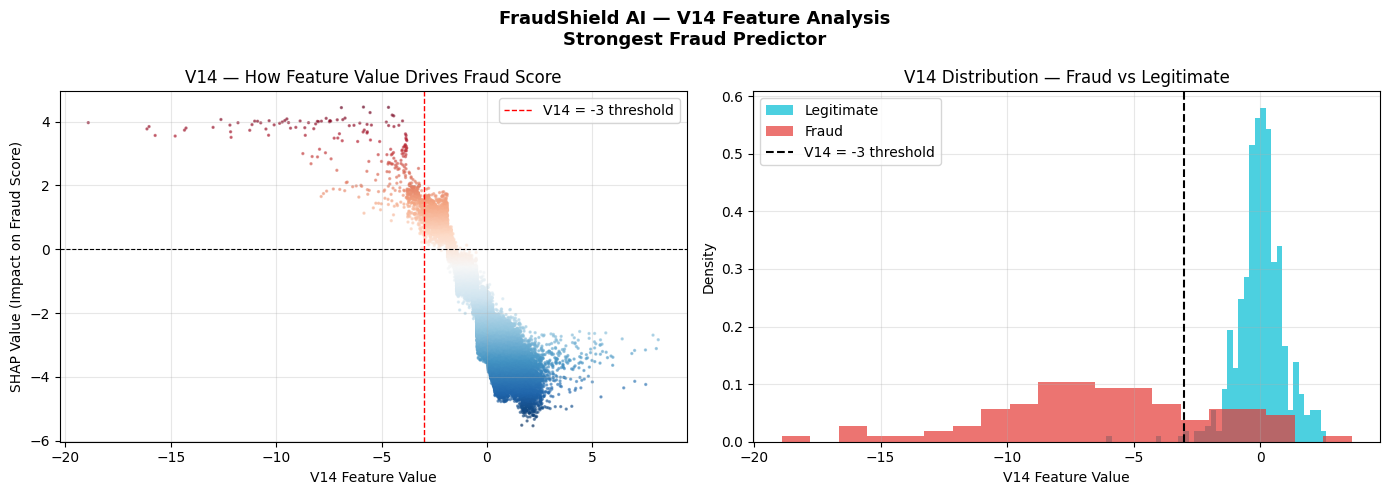

V14 FRAUD THRESHOLD ANALYSIS
Fraud V14 mean    : -6.271
Legit V14 mean    : 0.029
Separation        : 6.300

Key Rule:
V14 < -3 → High fraud probability
V14 > -1 → Low fraud probability


In [5]:
# ── SHAP Dependence Plot — V14 ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FraudShield AI — V14 Feature Analysis\n"
             "Strongest Fraud Predictor",
             fontsize=13, fontweight='bold')

# Plot 1 — V14 SHAP values vs feature value
axes[0].scatter(
    X_test_df['V14'],
    shap_values[:, feature_cols.index('V14')],
    c=shap_values[:, feature_cols.index('V14')],
    cmap='RdBu_r', alpha=0.5, s=2
)
axes[0].axhline(y=0, color='black',
                linewidth=0.8, linestyle='--')
axes[0].axvline(x=-3, color='red',
                linewidth=1, linestyle='--',
                label='V14 = -3 threshold')
axes[0].set_xlabel("V14 Feature Value")
axes[0].set_ylabel("SHAP Value (Impact on Fraud Score)")
axes[0].set_title("V14 — How Feature Value Drives Fraud Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — V14 distribution for fraud vs legitimate
fraud_v14 = X_test_df.iloc[
    y_test.reset_index(drop=True)[
        y_test.reset_index(drop=True)==1].index]['V14']
legit_v14 = X_test_df.iloc[
    y_test.reset_index(drop=True)[
        y_test.reset_index(drop=True)==0].index]['V14'].sample(500)

axes[1].hist(legit_v14, bins=40, alpha=0.7,
             color='#00bcd4', label='Legitimate',
             density=True)
axes[1].hist(fraud_v14, bins=20, alpha=0.7,
             color='#e53935', label='Fraud',
             density=True)
axes[1].axvline(x=-3, color='black',
                linewidth=1.5, linestyle='--',
                label='V14 = -3 threshold')
axes[1].set_xlabel("V14 Feature Value")
axes[1].set_ylabel("Density")
axes[1].set_title("V14 Distribution — Fraud vs Legitimate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('shap_v14_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("V14 FRAUD THRESHOLD ANALYSIS")
print("=" * 50)
print(f"Fraud V14 mean    : {fraud_v14.mean():.3f}")
print(f"Legit V14 mean    : {legit_v14.mean():.3f}")
print(f"Separation        : {abs(fraud_v14.mean() - legit_v14.mean()):.3f}")
print("\nKey Rule:")
print("V14 < -3 → High fraud probability")
print("V14 > -1 → Low fraud probability")

## Day 3 Summary

Explainability Method: SHAP TreeExplainer

Key Results:
- Top 5 features  : V14, V4, V12, V10, V3
- V14 separation  : 6.3 standard deviations
- Fraud prob      : 99.6% correctly identified
- Legit prob      : 0.0% correctly identified

Key Insights:
1. V14 < -3 → High fraud probability (mean=-6.271)
2. V14 > -1 → Low fraud probability (mean=+0.029)
3. SHAP waterfall explains every individual decision
4. Regulatory compliance — every flagged transaction
   can be explained to customer and regulator

Next: Day 4 — Autoencoder Anomaly Detection